# Lezione 6 - Esercizio 2

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy import fft

In [4]:
X_test = np.load('test_data.npy')
Y_test = np.load('test_label.npy')

X_train = np.load('training_data.npy')
Y_train = np.load('training_label.npy')

print(f'training dataset shape: {X_train.shape}')
print(f'test dataset shape: {X_test.shape}')

training dataset shape: (1490, 10, 1)
test dataset shape: (490, 10, 1)


In [5]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(X_train.shape[1], 1)))
model.add(tf.keras.layers.LSTM(units=30, 
                               activation='leaky_relu'))
model.add(tf.keras.layers.Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, Y_train, epochs=100, batch_size=32)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2849  
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0157
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0107
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0095
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0090
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0089
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0086
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0083
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0079
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0076
Epoch 12/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0071
Epoch 13/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0067
Epoch 14/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0062
Epoch 15/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0059
Ep

In [6]:
Y_pred = model.predict(X_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


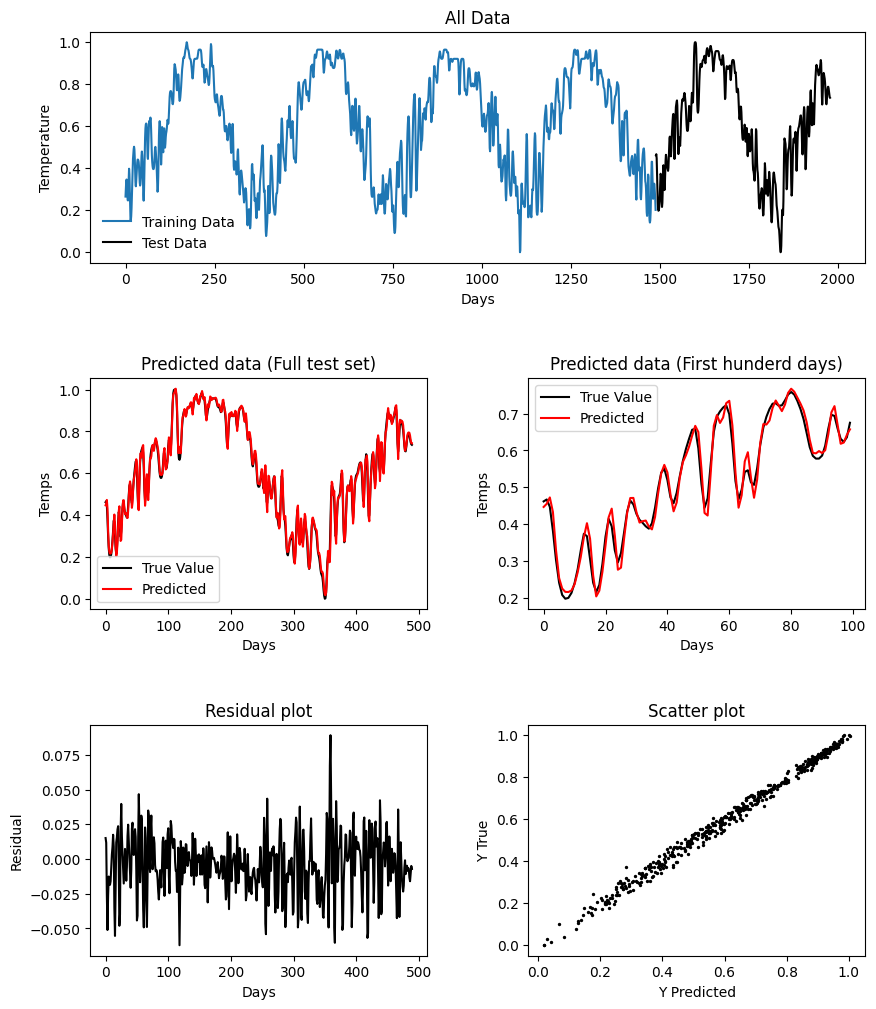

In [ ]:
plt.figure(figsize=(10,12))
plt.subplot(3,1,1)
plt.plot(Y_train, label='Training Data')
plt.plot(range(len(Y_train), len(Y_train) + len(Y_test)), Y_test, 'k', label='Test Data')

plt.legend(frameon=False)
plt.ylabel("Temperature")
plt.xlabel("Days")
plt.title("All Data")

plt.subplot(3,2,3)
plt.plot(Y_test, color='k', label='True Value')
plt.plot(Y_pred, color='r', label='Predicted')

plt.legend(frameon=True)
plt.ylabel('Temps')
plt.xlabel('Days')
plt.title('Predicted data (Full test set)')

plt.subplot(3,2,4)
plt.plot(Y_test[0:100], color='k', label='True Value')
plt.plot(Y_pred[0:100], color='r', label='Predicted')

plt.legend(frameon=True)
plt.ylabel('Temps')
plt.xlabel('Days')
plt.title('Predicted data (First hunderd days)')

plt.subplot(3,2,5)
plt.plot(Y_test-Y_pred, color='k')
plt.ylabel('Residual')
plt.xlabel("Days")
plt.title("Residual plot")

plt.subplot(3, 2, 6)
plt.scatter(Y_pred, Y_test, s=2, color='k')
plt.ylabel('Y True')
plt.xlabel("Y Predicted")
plt.title("Scatter plot")

plt.subplots_adjust(hspace=.5, wspace=.3)

C'e' un ritardo della predizione, per poche epoche, dobbiamo quindi cercare di tunare meglio quel valore (siamo partiti da 5 epoche)

In [11]:
Y_train

array([[0.26495052],
       [0.30732492],
       [0.33787998],
       ...,
       [0.28241603],
       [0.25101759],
       [0.20145129]], shape=(1490, 1))

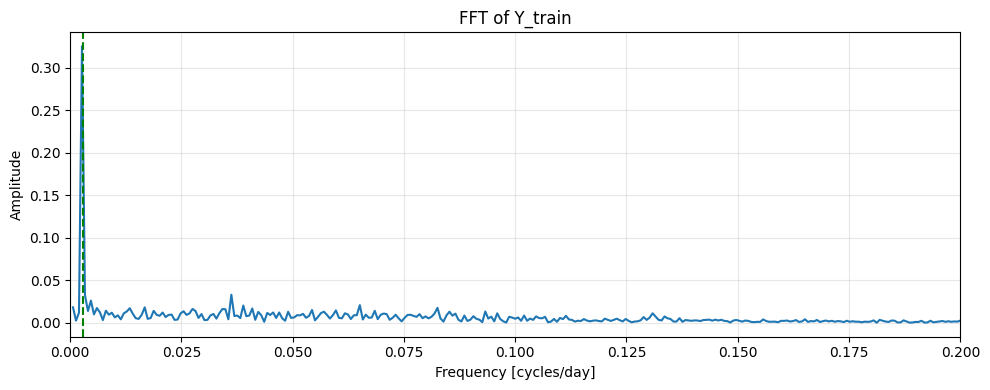

In [97]:
from scipy.fft import fft, fftfreq

# Flatten and de-mean the signal to reduce the DC component
y = np.asarray(Y_train).squeeze()
y = y - np.mean(y)

N = len(y)
dt = 1.0  # one sample per day

yf = fft(y)
xf = fftfreq(N, d=dt)

# Keep only positive frequencies
pos = xf > 0
amplitude = 2.0 / N * np.abs(yf[pos])

max_freq = xf[np.argmax(amplitude)]

plt.figure(figsize=(10, 4))
plt.plot(xf[pos], amplitude)
plt.axvline(np.mean(amplitude), linestyle='--', c='green')
plt.title('FFT of Y_train')
plt.xlabel('Frequency [cycles/day]')
plt.ylabel('Amplitude')
plt.xlim(0,0.2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [98]:
2.75/2 * max_freq

np.float64(0.002768456375838926)

In [114]:
np.mean(amplitude)

np.float64(0.0029165966400489136)

In [115]:
1.9*np.mean(amplitude)/2

np.float64(0.002770766808046468)

In [117]:
2.75*max_freq/2

np.float64(0.002768456375838926)

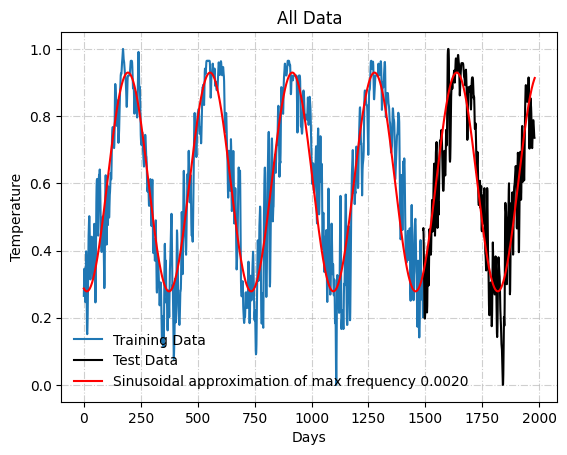

In [118]:
x = np.linspace(0, len(Y_train) + len(Y_test), 10000)
plt.plot(Y_train, label='Training Data')
plt.plot(range(len(Y_train), len(Y_train) + len(Y_test)), Y_test, 'k', label='Test Data')
plt.plot(x, np.sin(x*1.9*np.pi*np.mean(amplitude) - 1.8)*np.max(amplitude) + np.mean(Y_train), color='red', label=f'Sinusoidal approximation of max frequency {max_freq:0.4f}')

plt.legend(frameon=False)
plt.ylabel("Temperature")
plt.xlabel("Days")
plt.title("All Data")
plt.grid(alpha=0.6, linestyle='-.')